In [26]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [27]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [28]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def show_results(model, df_train_full, df_test, target_col, exog_cols):
    last_window = df_train_full[target_col].iloc[-len(model.lags):]
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols],
                last_window = last_window
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast(df_train_full[target_col], df_test[target_col], y_pred)
    
def fit_best_model(df_train, best_params, target_col, exog_cols):
    best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
    best_model.fit(
                y=df_train[target_col],
                exog=df_train[exog_cols],
            )
    return best_model

In [29]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [30]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

Глубина 0

In [31]:
depth = 0
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [32]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:08:21,462] A new study created in memory with name: no-name-bd51f729-7856-41da-9180-04da4ac7cc8a
[I 2026-05-12 17:08:21,677] Trial 0 finished with value: 3.714361020262643 and parameters: {'lags': 5, 'n_estimators': 690, 'learning_rate': 0.17224416289485858, 'max_depth': 1, 'subsample': 0.444043623419207, 'colsample_bytree': 0.8882252732155619, 'colsample_bylevel': 0.8540308362573429, 'colsample_bynode': 0.7501185569714264, 'reg_alpha': 0.05890345582911772, 'reg_lambda': 0.019529655097346527, 'gamma': 0.009279581310901869, 'min_child_weight': 14, 'max_delta_step': 3}. Best is trial 0 with value: 3.714361020262643.
[I 2026-05-12 17:08:21,821] Trial 1 finished with value: 3.3705582534698593 and parameters: {'lags': 3, 'n_estimators': 496, 'learning_rate': 0.13357542016066348, 'max_depth': 2, 'subsample': 0.9644684371643679, 'colsample_bytree': 0.8348982644488174, 'colsample_bylevel': 0.41976311737722793, 'colsample_bynode': 0.9587868099158005, 'reg_alpha': 3.737327841067

Лучшие параметры = {'lags': 1, 'n_estimators': 347, 'learning_rate': 0.28801382065093445, 'max_depth': 7, 'subsample': 0.7032377983166689, 'colsample_bytree': 0.801545443349545, 'colsample_bylevel': 0.584980737510944, 'colsample_bynode': 0.8032504756581698, 'reg_alpha': 2.1811828814229224, 'reg_lambda': 0.1784398624019818, 'gamma': 1.2986983564059326e-05, 'min_child_weight': 13, 'max_delta_step': 16}
Лучший RMSE score = 3.098337484837054


In [33]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_0']

RMSE на тесте = 2.811181368394948


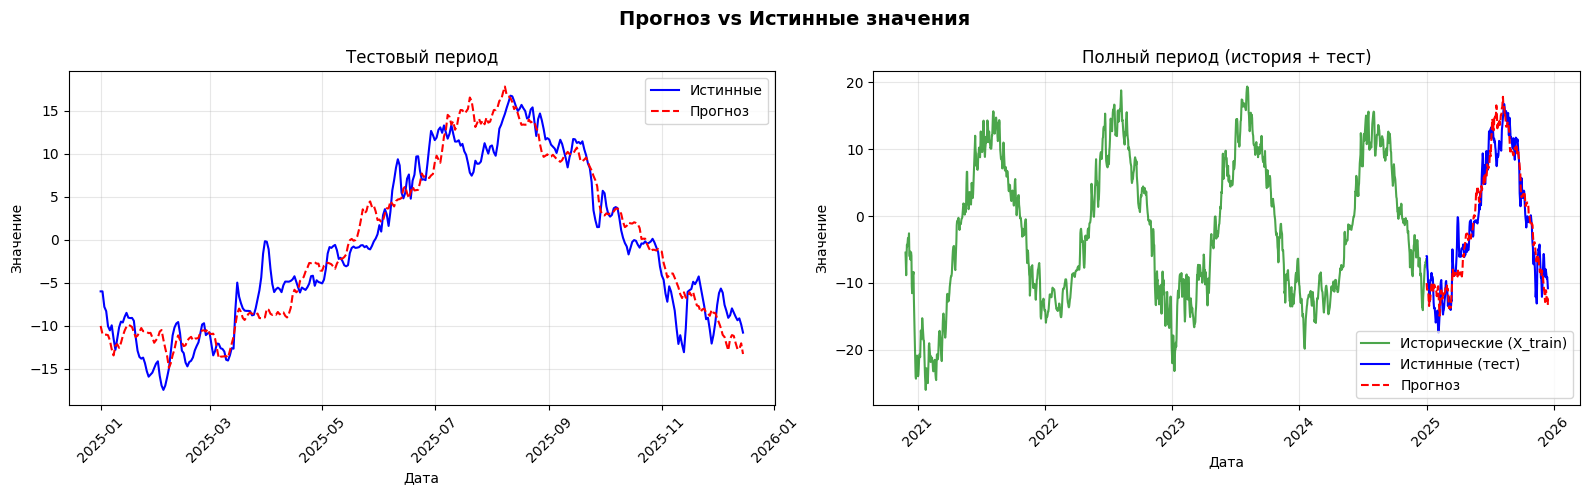

,feature,importance
2,Месяц_cos,0.610132
4,day_of_year_cos,0.122691
0,lag_1,0.119222
1,Месяц_sin,0.088868
3,day_of_year_sin,0.059087


In [34]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 3

In [35]:
depth = 3
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [36]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:08:34,922] A new study created in memory with name: no-name-b138d33b-d1ca-4277-a706-a241758a4a38
[I 2026-05-12 17:08:35,285] Trial 0 finished with value: 1.376090017739806 and parameters: {'lags': 4, 'n_estimators': 708, 'learning_rate': 0.04528864113996289, 'max_depth': 7, 'subsample': 0.5423993011237307, 'colsample_bytree': 0.8087871011988463, 'colsample_bylevel': 0.5551586248451224, 'colsample_bynode': 0.9055074643568273, 'reg_alpha': 0.06856794525498087, 'reg_lambda': 0.8562839806306727, 'gamma': 0.00027635941216846017, 'min_child_weight': 9, 'max_delta_step': 9}. Best is trial 0 with value: 1.376090017739806.
[I 2026-05-12 17:08:35,496] Trial 1 finished with value: 2.804508920725489 and parameters: {'lags': 5, 'n_estimators': 214, 'learning_rate': 0.001570965073087226, 'max_depth': 9, 'subsample': 0.9911747394775617, 'colsample_bytree': 0.6050021164780978, 'colsample_bylevel': 0.8791073720149055, 'colsample_bynode': 0.5707848652897445, 'reg_alpha': 0.0001003178030

Лучшие параметры = {'lags': 3, 'n_estimators': 606, 'learning_rate': 0.05847406068861366, 'max_depth': 3, 'subsample': 0.6721701012213084, 'colsample_bytree': 0.6575605706394168, 'colsample_bylevel': 0.6479703262458697, 'colsample_bynode': 0.8393439896055255, 'reg_alpha': 0.05647165272054274, 'reg_lambda': 0.00014456738320728382, 'gamma': 0.04648564333774038, 'min_child_weight': 1, 'max_delta_step': 17}
Лучший RMSE score = 0.8075773893345579


In [37]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_3']

RMSE на тесте = 0.9309654248127351


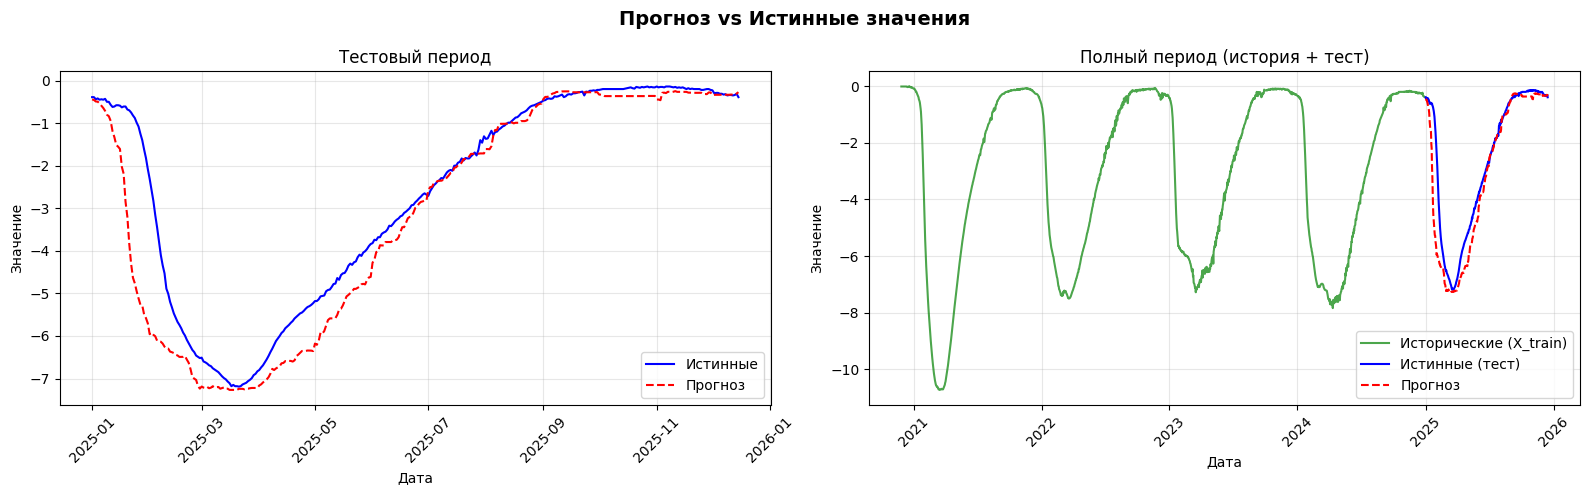

,feature,importance
1,lag_2,0.270172
3,Месяц_sin,0.227713
0,lag_1,0.206902
5,day_of_year_sin,0.135623
2,lag_3,0.101973
6,day_of_year_cos,0.033611
4,Месяц_cos,0.024006


In [38]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 5

In [39]:
depth = 5
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [40]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:08:44,459] A new study created in memory with name: no-name-f6e1f3b9-4291-424e-a1c0-c36a59743939
[I 2026-05-12 17:08:44,619] Trial 0 finished with value: 0.6168979570243807 and parameters: {'lags': 5, 'n_estimators': 724, 'learning_rate': 0.22422138409480752, 'max_depth': 9, 'subsample': 0.5530900320109393, 'colsample_bytree': 0.5098849889338677, 'colsample_bylevel': 0.43929033643879234, 'colsample_bynode': 0.803448947770995, 'reg_alpha': 0.00012123915439014568, 'reg_lambda': 0.04333124083419236, 'gamma': 0.29148250316401947, 'min_child_weight': 8, 'max_delta_step': 19}. Best is trial 0 with value: 0.6168979570243807.
[I 2026-05-12 17:08:44,898] Trial 1 finished with value: 1.7267421858845349 and parameters: {'lags': 1, 'n_estimators': 471, 'learning_rate': 0.0008125622809477019, 'max_depth': 6, 'subsample': 0.8544870321342989, 'colsample_bytree': 0.9969620773858653, 'colsample_bylevel': 0.841890570538635, 'colsample_bynode': 0.6723507102022264, 'reg_alpha': 0.16120982

Лучшие параметры = {'lags': 5, 'n_estimators': 724, 'learning_rate': 0.22422138409480752, 'max_depth': 9, 'subsample': 0.5530900320109393, 'colsample_bytree': 0.5098849889338677, 'colsample_bylevel': 0.43929033643879234, 'colsample_bynode': 0.803448947770995, 'reg_alpha': 0.00012123915439014568, 'reg_lambda': 0.04333124083419236, 'gamma': 0.29148250316401947, 'min_child_weight': 8, 'max_delta_step': 19}
Лучший RMSE score = 0.6168979570243807


In [41]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_5']

RMSE на тесте = 0.5946128239952053


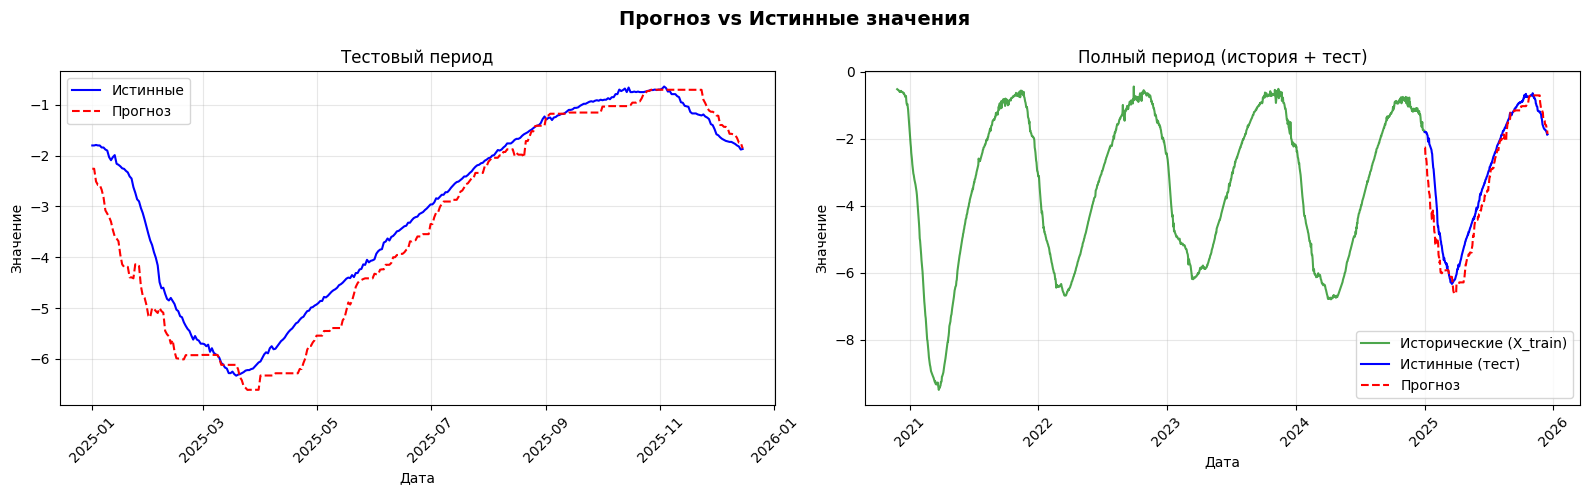

,feature,importance
2,lag_3,0.384829
5,Месяц_sin,0.182035
0,lag_1,0.159984
1,lag_2,0.126290
6,Месяц_cos,0.043767
7,day_of_year_sin,0.039426
4,lag_5,0.029245
8,day_of_year_cos,0.024087
3,lag_4,0.010337


In [42]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 7

In [43]:
depth = 7
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [44]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:08:57,075] A new study created in memory with name: no-name-03a857f5-1732-46b3-abdc-2eb49ef2faca
[I 2026-05-12 17:08:57,186] Trial 0 finished with value: 0.5261651729658612 and parameters: {'lags': 2, 'n_estimators': 317, 'learning_rate': 0.13975138254310535, 'max_depth': 1, 'subsample': 0.8231191956992279, 'colsample_bytree': 0.6593226966966124, 'colsample_bylevel': 0.8581862346749501, 'colsample_bynode': 0.9342849383567798, 'reg_alpha': 0.03951652164109619, 'reg_lambda': 0.024081011808720486, 'gamma': 0.0011329264837497306, 'min_child_weight': 11, 'max_delta_step': 12}. Best is trial 0 with value: 0.5261651729658612.
[I 2026-05-12 17:08:57,447] Trial 1 finished with value: 1.592347272685117 and parameters: {'lags': 3, 'n_estimators': 469, 'learning_rate': 0.0006401908371066155, 'max_depth': 5, 'subsample': 0.4965391104050677, 'colsample_bytree': 0.45040617551238454, 'colsample_bylevel': 0.47033343884844536, 'colsample_bynode': 0.5281911014484826, 'reg_alpha': 4.74770

Лучшие параметры = {'lags': 2, 'n_estimators': 317, 'learning_rate': 0.13975138254310535, 'max_depth': 1, 'subsample': 0.8231191956992279, 'colsample_bytree': 0.6593226966966124, 'colsample_bylevel': 0.8581862346749501, 'colsample_bynode': 0.9342849383567798, 'reg_alpha': 0.03951652164109619, 'reg_lambda': 0.024081011808720486, 'gamma': 0.0011329264837497306, 'min_child_weight': 11, 'max_delta_step': 12}
Лучший RMSE score = 0.5261651729658612


In [45]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_7']

RMSE на тесте = 0.5797569385973771


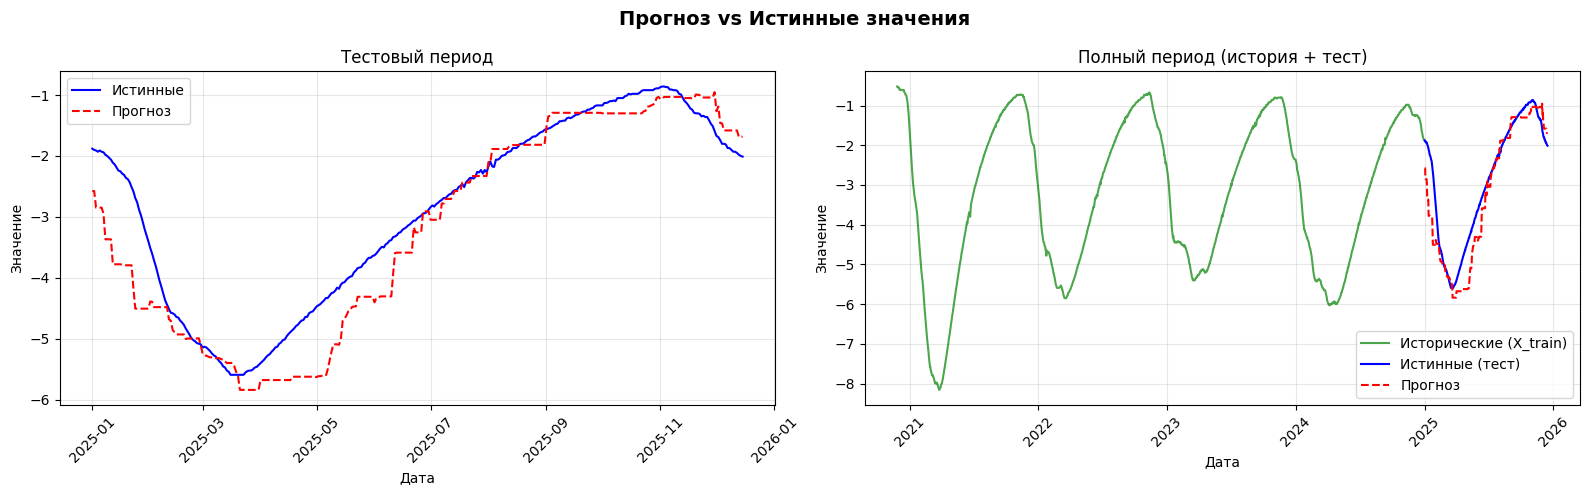

,feature,importance
4,day_of_year_sin,0.561625
0,lag_1,0.232009
1,lag_2,0.114208
2,Месяц_sin,0.072760
5,day_of_year_cos,0.012594
3,Месяц_cos,0.006804


In [46]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 10

In [47]:
depth = 10
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [48]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:09:15,513] A new study created in memory with name: no-name-3bc8a65c-e38d-430c-a78e-9806759a26ea
[I 2026-05-12 17:09:15,680] Trial 0 finished with value: 0.6893493641655326 and parameters: {'lags': 3, 'n_estimators': 628, 'learning_rate': 0.0014743238967867742, 'max_depth': 2, 'subsample': 0.9279437206916007, 'colsample_bytree': 0.5324720330375574, 'colsample_bylevel': 0.533754442584909, 'colsample_bynode': 0.698125829447328, 'reg_alpha': 0.16184054856846633, 'reg_lambda': 0.00795260910131681, 'gamma': 1.739265745397097e-05, 'min_child_weight': 5, 'max_delta_step': 15}. Best is trial 0 with value: 0.6893493641655326.
[I 2026-05-12 17:09:15,874] Trial 1 finished with value: 0.40873138266819664 and parameters: {'lags': 3, 'n_estimators': 660, 'learning_rate': 0.1016566120042014, 'max_depth': 7, 'subsample': 0.735830041786321, 'colsample_bytree': 0.6599523840968118, 'colsample_bylevel': 0.8367740256721377, 'colsample_bynode': 0.5457483919960403, 'reg_alpha': 6.40261901050

Лучшие параметры = {'lags': 5, 'n_estimators': 235, 'learning_rate': 0.0398607983466673, 'max_depth': 2, 'subsample': 0.7405116495111886, 'colsample_bytree': 0.6719279650314636, 'colsample_bylevel': 0.9769280725623527, 'colsample_bynode': 0.4636159306868787, 'reg_alpha': 0.0012740227362318913, 'reg_lambda': 2.5656385199205147e-05, 'gamma': 0.0006297399634821422, 'min_child_weight': 13, 'max_delta_step': 7}
Лучший RMSE score = 0.3270654086494967


In [49]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_10']

RMSE на тесте = 0.3307130892421802


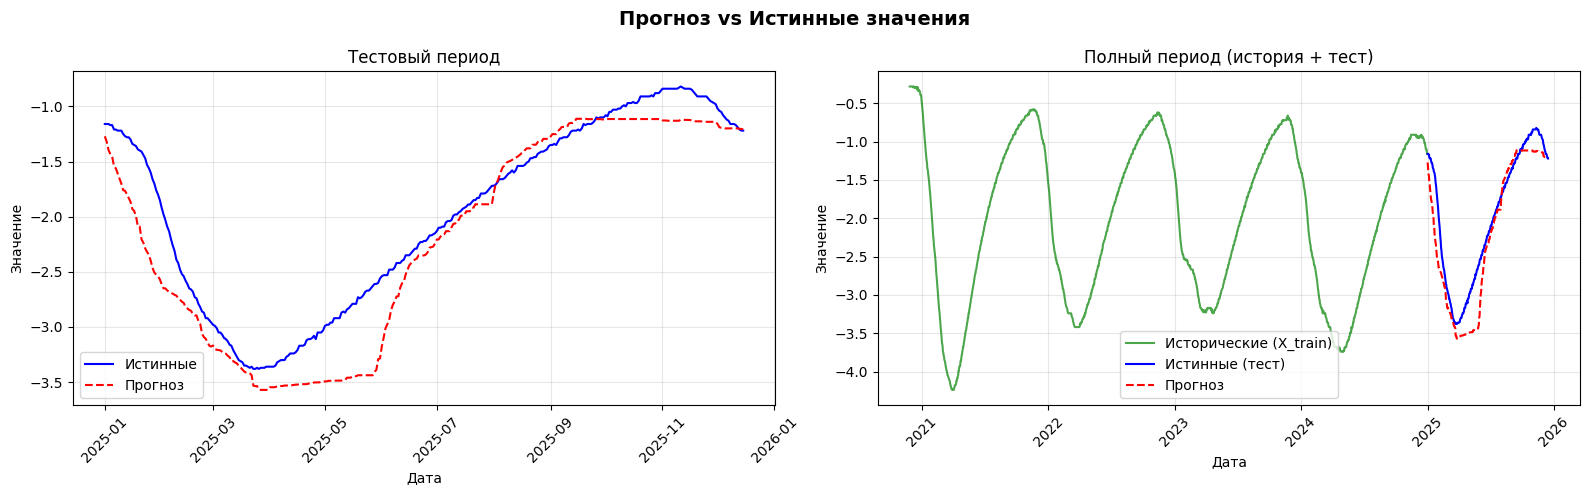

,feature,importance
1,lag_2,0.230327
2,lag_3,0.194031
0,lag_1,0.190099
4,lag_5,0.133408
3,lag_4,0.094140
7,day_of_year_sin,0.077310
5,Месяц_sin,0.061558
8,day_of_year_cos,0.011059
6,Месяц_cos,0.008069


In [50]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances